# Walmart Sales EDA Project

This notebook has a exploratory data analysis of the Walmart dataset and adds clear business conclusions based on the data.

## Objectives
- Load and clean the dataset
- Explore the structure and quality of the data
- Analyze sales patterns by category, product, store, time, and promotions
- Compare forecasted demand vs actual demand
- Summarize the key findings with business-oriented conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
def load_and_process_data(file_path: str) -> pd.DataFrame:
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()
    data['transaction_date'] = pd.to_datetime(
        data['transaction_date'].astype('string').str.replace(r'\\s+', ' ', regex=True).str.strip(),
        errors='coerce'
    )
    data = data.dropna(subset=['transaction_date']).copy()
    data['promotion_type'] = data['promotion_type'].fillna('No Promotion')
    data['sales_amount'] = data['quantity_sold'] * data['unit_price']
    data['month'] = data['transaction_date'].dt.month_name()
    data['month_num'] = data['transaction_date'].dt.month
    data['day_name'] = data['transaction_date'].dt.day_name()
    data['demand_gap'] = data['actual_demand'] - data['forecasted_demand']
    print('Dataset loaded successfully.')
    return data

csv_path = '/mnt/data/Walmart.csv'
data = load_and_process_data(csv_path)
print(f'Shape: {data.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Walmart.csv'

In [3]:
print(data.head())
print('\nData types:\n')
print(data.dtypes)
print('\nMissing values:\n')
print(data.isna().sum())

   transaction_id  customer_id  product_id product_name     category  \
0               1         2824         843       Fridge  Electronics   
1               2         1409         135           TV  Electronics   
2               3         5506         391       Fridge  Electronics   
3               4         5012         710   Smartphone  Electronics   
4               5         4657         116       Laptop  Electronics   

   quantity_sold  unit_price    transaction_date  store_id   store_location  \
0              3      188.46 2024-03-31 21:46:00         3        Miami, FL   
1              4    1,912.04 2024-07-28 12:45:00         5       Dallas, TX   
2              4    1,377.75 2024-06-10 04:55:00         1  Los Angeles, CA   
3              5      182.31 2024-08-15 01:03:00         5        Miami, FL   
4              3      499.28 2024-09-13 00:45:00         6      Chicago, IL   

   inventory_level  reorder_point  reorder_quantity  supplier_id  \
0              246      

## 1. Descriptive statistics
We begin by understanding the overall numerical behavior of the dataset.

In [4]:
summary_stats = data.describe(include='all')
summary_stats

,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,sales_amount,month,month_num,day_name,demand_gap
count,"5,000.00","5,000.00","5,000.00",5000,5000,"5,000.00","5,000.00",5000,"5,000.00",5000,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00",5000,"5,000.00",5000,5000,5000,5000,5000,5000,5000,5000,"5,000.00","5,000.00","5,000.00",5000,"5,000.00",5000,"5,000.00"
unique,NaN,NaN,NaN,8,2,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,4,4,2,3,4,2,7,2,NaN,NaN,NaN,9,NaN,7,NaN
top,NaN,NaN,NaN,Fridge,Electronics,NaN,NaN,NaN,NaN,"Los Angeles, CA",NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,Platinum,Credit Card,True,No Promotion,Cloudy,False,Monday,True,NaN,NaN,NaN,August,NaN,Monday,NaN
freq,NaN,NaN,NaN,655,2585,NaN,NaN,NaN,NaN,1038,NaN,NaN,NaN,NaN,NaN,NaN,1682,NaN,1299,1281,2607,3407,1281,2501,775,2593,NaN,NaN,NaN,656,NaN,770,NaN
mean,"2,500.50","5,542.50",551.23,NaN,NaN,2.98,"1,023.47",2024-05-11 05:10:22.740000,10.53,NaN,253.12,99.79,200.52,300.13,5.52,44.12,NaN,"70,041.63",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,297.13,299.09,"3,052.72",NaN,4.83,NaN,1.95
min,1.00,"1,001.00",100.00,NaN,NaN,1.00,50.10,2024-01-01 00:31:00,1.00,NaN,0.00,50.00,100.00,100.00,1.00,18.00,NaN,"20,005.34",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00,90.00,50.10,NaN,1.00,NaN,-406.00
25%,"1,250.75","3,279.00",322.00,NaN,NaN,2.00,537.78,2024-03-07 19:21:15,5.00,NaN,130.00,75.00,150.75,199.00,3.00,31.00,NaN,"44,865.42",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.00,194.00,"1,161.50",NaN,3.00,NaN,-116.00
50%,"2,500.50","5,558.00",559.00,NaN,NaN,3.00,"1,029.17",2024-05-11 20:02:30,11.00,NaN,253.00,100.00,200.50,299.00,6.00,44.00,NaN,"70,188.29",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,297.50,299.00,"2,386.44",NaN,5.00,NaN,5.00
75%,"3,750.25","7,767.25",776.00,NaN,NaN,4.00,"1,506.31",2024-07-16 08:58:15,16.00,NaN,377.25,125.00,251.00,405.00,8.00,58.00,NaN,"95,395.87",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,395.00,404.00,"4,524.21",NaN,7.00,NaN,123.25
max,"5,000.00","9,998.00",999.00,NaN,NaN,5.00,"1,999.85",2024-09-16 20:22:00,20.00,NaN,500.00,150.00,300.00,500.00,10.00,70.00,NaN,"119,999.78",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.00,510.00,"9,999.25",NaN,9.00,NaN,400.00


In [5]:
metrics = pd.DataFrame({
    'Metric': [
        'Total Transactions',
        'Total Revenue',
        'Average Revenue per Transaction',
        'Total Units Sold',
        'Average Unit Price',
        'Average Forecast Error (Actual - Forecasted)',
        'Mean Absolute Forecast Error'
    ],
    'Value': [
        len(data),
        data['sales_amount'].sum(),
        data['sales_amount'].mean(),
        data['quantity_sold'].sum(),
        data['unit_price'].mean(),
        data['demand_gap'].mean(),
        data['demand_gap'].abs().mean()
    ]
})
metrics

,Metric,Value
0,Total Transactions,"5,000.00"
1,Total Revenue,"15,263,601.45"
2,Average Revenue per Transaction,"3,052.72"
3,Total Units Sold,"14,914.00"
4,Average Unit Price,"1,023.47"
5,Average Forecast Error (Actual - Forecasted),1.95
6,Mean Absolute Forecast Error,137.52


## 2. Sales by category and product
This section identifies which product groups and items generate the most revenue.

In [6]:
category_sales = data.groupby('category', as_index=False).agg(
    total_revenue=('sales_amount', 'sum'),
    total_units_sold=('quantity_sold', 'sum'),
    avg_transaction_value=('sales_amount', 'mean')
).sort_values('total_revenue', ascending=False)
category_sales

,category,total_revenue,total_units_sold,avg_transaction_value
1,Electronics,"7,941,631.80",7745,"3,072.20"
0,Appliances,"7,321,969.65",7169,"3,031.87"


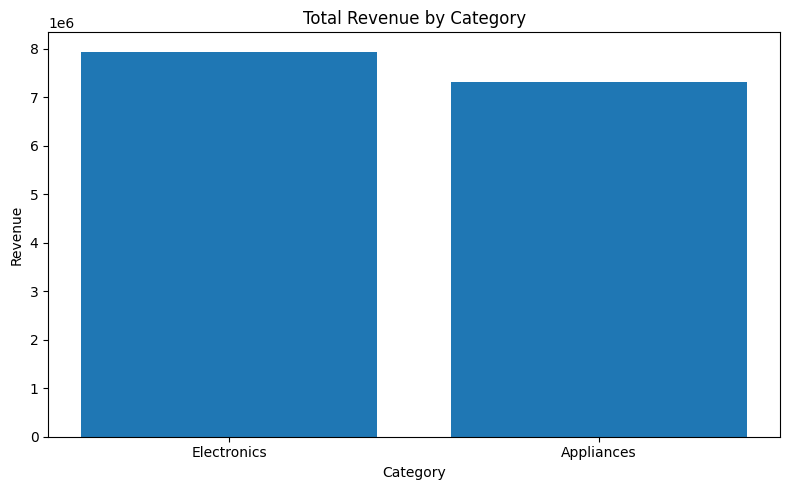

In [7]:
plt.figure(figsize=(8,5))
plt.bar(category_sales['category'], category_sales['total_revenue'])
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [8]:
product_sales = data.groupby('product_name', as_index=False).agg(
    total_revenue=('sales_amount', 'sum'),
    total_units_sold=('quantity_sold', 'sum')
).sort_values('total_revenue', ascending=False)
product_sales.head(10)

,product_name,total_revenue,total_units_sold
5,TV,"2,049,493.86",1926
6,Tablet,"1,996,253.02",1964
1,Fridge,"1,938,012.69",1967
4,Smartphone,"1,931,310.04",1876
7,Washing Machine,"1,897,934.02",1807
0,Camera,"1,895,104.13",1873
2,Headphones,"1,846,334.45",1816
3,Laptop,"1,709,159.24",1685


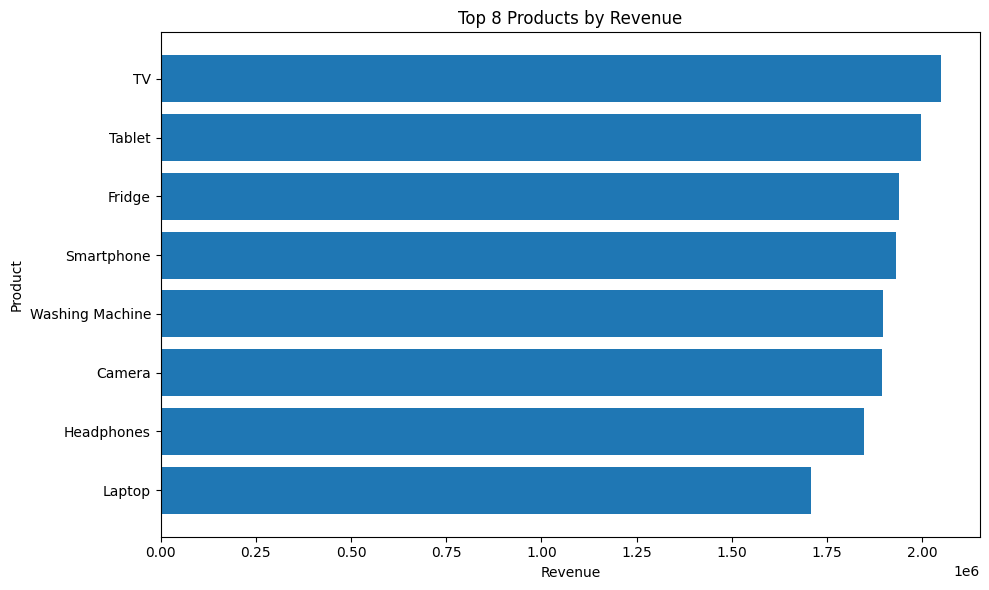

In [9]:
top_products = product_sales.head(8).sort_values('total_revenue')
plt.figure(figsize=(10,6))
plt.barh(top_products['product_name'], top_products['total_revenue'])
plt.title('Top 8 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

## 3. Store performance
We compare the revenue generated across store locations.

In [10]:
store_sales = data.groupby('store_location', as_index=False).agg(
    total_revenue=('sales_amount', 'sum'),
    total_units_sold=('quantity_sold', 'sum'),
    avg_transaction_value=('sales_amount', 'mean')
).sort_values('total_revenue', ascending=False)
store_sales

,store_location,total_revenue,total_units_sold,avg_transaction_value
2,"Los Angeles, CA","3,276,299.63",3168,"3,156.36"
0,"Chicago, IL","3,156,726.82",3085,"3,116.22"
4,"New York, NY","2,964,077.24",2935,"3,003.12"
3,"Miami, FL","2,962,567.02",2834,"3,073.20"
1,"Dallas, TX","2,903,930.74",2892,"2,909.75"


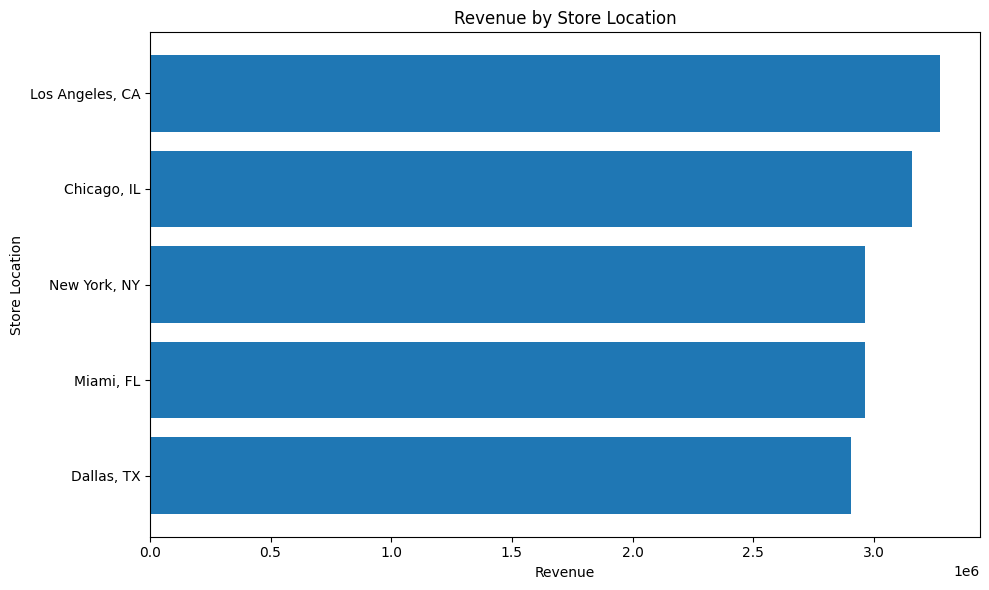

In [11]:
stores_plot = store_sales.sort_values('total_revenue')
plt.figure(figsize=(10,6))
plt.barh(stores_plot['store_location'], stores_plot['total_revenue'])
plt.title('Revenue by Store Location')
plt.xlabel('Revenue')
plt.ylabel('Store Location')
plt.tight_layout()
plt.show()

## 4. Time-based analysis
This helps identify the strongest periods in the dataset.

In [12]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales = data.groupby(['month_num', 'month'], as_index=False)['sales_amount'].sum().sort_values('month_num')
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')
monthly_sales

,month_num,month,sales_amount
0,1,January,"1,731,651.65"
1,2,February,"1,767,062.38"
2,3,March,"1,833,450.84"
3,4,April,"1,739,800.75"
4,5,May,"1,786,559.47"
5,6,June,"1,600,978.97"
6,7,July,"1,878,513.51"
7,8,August,"2,018,315.81"
8,9,September,"907,268.07"


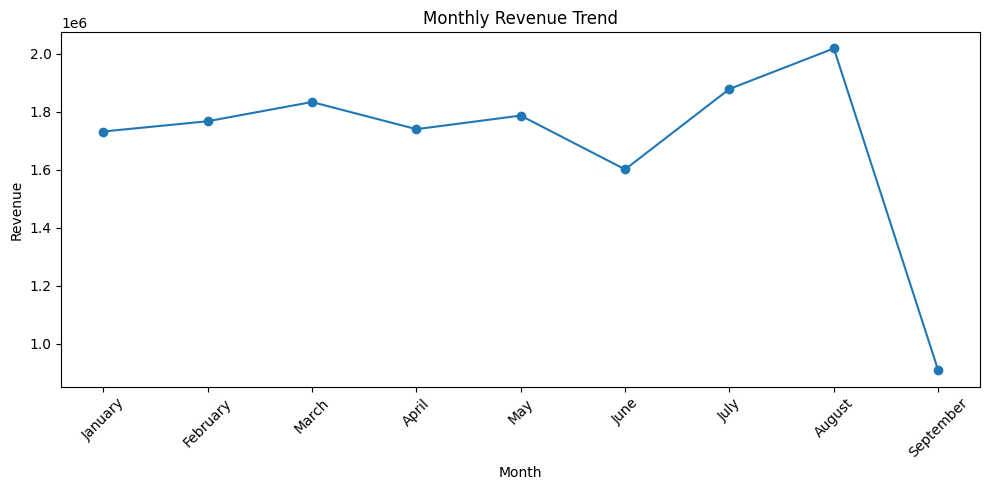

In [13]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['sales_amount'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = data.groupby('weekday', as_index=False).agg(
    total_revenue=('sales_amount', 'sum'),
    avg_units_sold=('quantity_sold', 'mean')
)
weekday_sales['weekday'] = pd.Categorical(weekday_sales['weekday'], categories=weekday_order, ordered=True)
weekday_sales = weekday_sales.sort_values('weekday')
weekday_sales

,weekday,total_revenue,avg_units_sold
1,Monday,"2,433,795.67",3.01
5,Tuesday,"2,126,494.17",2.90
6,Wednesday,"2,095,912.06",3.00
4,Thursday,"2,436,640.72",3.07
0,Friday,"2,009,799.42",2.97
2,Saturday,"2,222,858.28",3.01
3,Sunday,"1,938,101.13",2.92


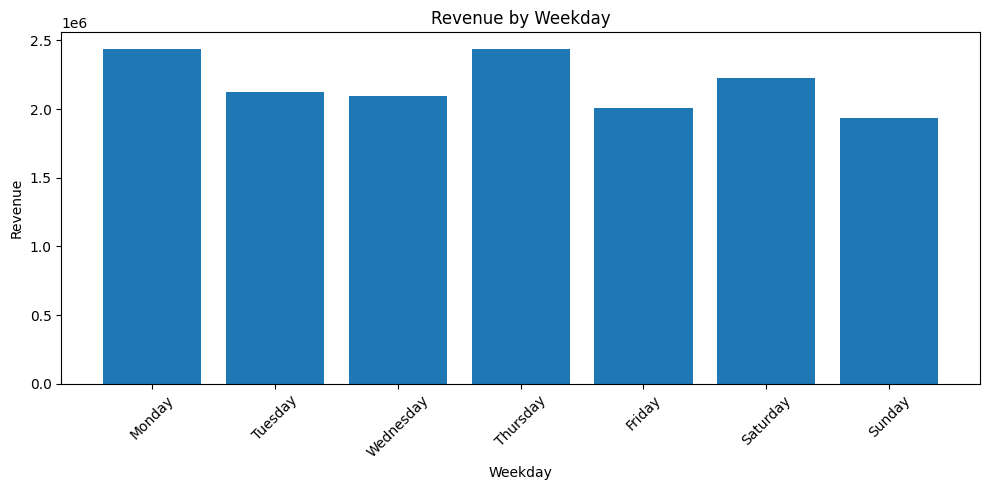

In [15]:
plt.figure(figsize=(10,5))
plt.bar(weekday_sales['weekday'].astype(str), weekday_sales['total_revenue'])
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Promotions, holidays, and customer behavior
Here we evaluate whether promotional and customer-related variables appear to influence sales.

In [16]:
promo_summary = data.groupby('promotion_applied', as_index=False).agg(
    avg_revenue=('sales_amount', 'mean'),
    avg_units_sold=('quantity_sold', 'mean'),
    avg_actual_demand=('actual_demand', 'mean')
)
promo_summary

,promotion_applied,avg_revenue,avg_units_sold,avg_actual_demand
0,False,"3,009.27",2.98,300.33
1,True,"3,092.60",2.98,297.95


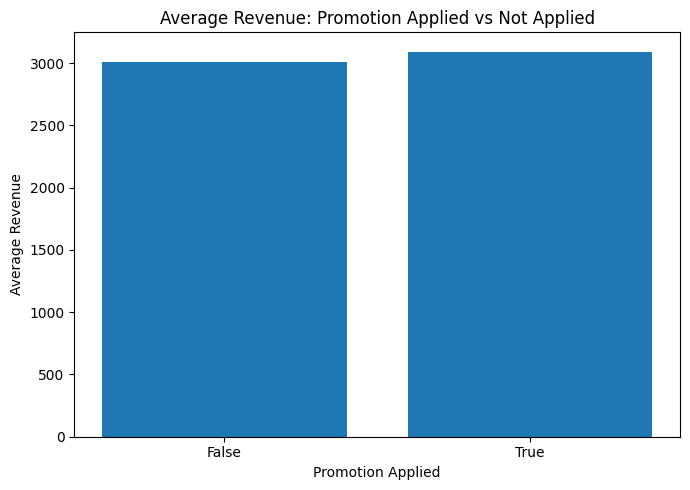

In [17]:
plt.figure(figsize=(7,5))
plt.bar(promo_summary['promotion_applied'].astype(str), promo_summary['avg_revenue'])
plt.title('Average Revenue: Promotion Applied vs Not Applied')
plt.xlabel('Promotion Applied')
plt.ylabel('Average Revenue')
plt.tight_layout()
plt.show()

In [18]:
promo_type_summary = data.groupby('promotion_type', as_index=False).agg(
    avg_revenue=('sales_amount', 'mean'),
    avg_units_sold=('quantity_sold', 'mean'),
    transactions=('transaction_id', 'count')
).sort_values('avg_revenue', ascending=False)
promo_type_summary

,promotion_type,avg_revenue,avg_units_sold,transactions
2,Percentage Discount,"3,105.76",3.01,773
0,BOGO,"3,091.45",3.01,820
1,No Promotion,"3,031.37",2.97,3407


In [19]:
loyalty_summary = data.groupby('customer_loyalty_level', as_index=False).agg(
    avg_revenue=('sales_amount', 'mean'),
    avg_income=('customer_income', 'mean')
).sort_values('avg_revenue', ascending=False)
loyalty_summary

,customer_loyalty_level,avg_revenue,avg_income
2,Platinum,"3,089.27","69,449.20"
1,Gold,"3,049.02","70,884.07"
3,Silver,"3,042.37","69,013.54"
0,Bronze,"3,028.89","70,932.70"


## 6. Inventory and demand analysis
This part compares forecasted demand with actual demand and explores stockout behavior.

In [20]:
stockout_summary = data.groupby('stockout_indicator', as_index=False).agg(
    avg_inventory=('inventory_level', 'mean'),
    avg_forecasted_demand=('forecasted_demand', 'mean'),
    avg_actual_demand=('actual_demand', 'mean'),
    avg_demand_gap=('demand_gap', 'mean'),
    transactions=('transaction_id', 'count')
)
stockout_summary

,stockout_indicator,avg_inventory,avg_forecasted_demand,avg_actual_demand,avg_demand_gap,transactions
0,False,254.50,295.50,298.71,3.21,2407
1,True,251.84,298.65,299.44,0.79,2593


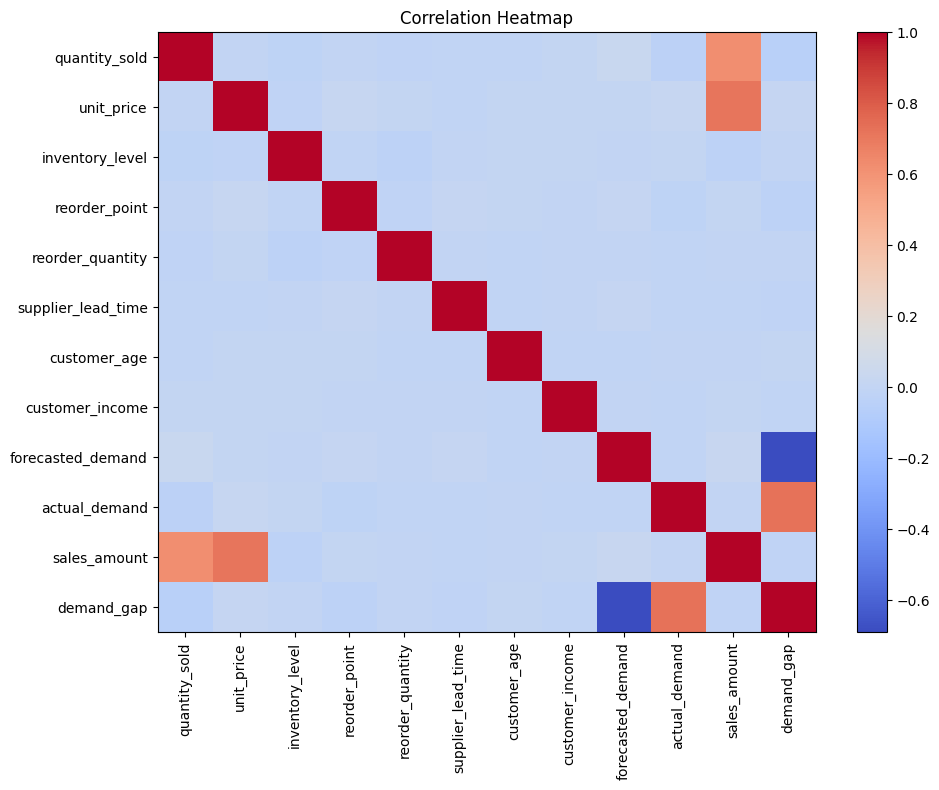

In [21]:
correlation_cols = [
    'quantity_sold', 'unit_price', 'inventory_level', 'reorder_point', 'reorder_quantity',
    'supplier_lead_time', 'customer_age', 'customer_income', 'forecasted_demand',
    'actual_demand', 'sales_amount', 'demand_gap'
]
corr = data[correlation_cols].corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=90)
plt.yticks(range(len(correlation_cols)), correlation_cols)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [22]:
store_demand_gap = data.groupby('store_location', as_index=False).agg(
    avg_demand_gap=('demand_gap', 'mean'),
    avg_actual_demand=('actual_demand', 'mean'),
    avg_forecasted_demand=('forecasted_demand', 'mean')
).sort_values('avg_demand_gap', ascending=False)
store_demand_gap

,store_location,avg_demand_gap,avg_actual_demand,avg_forecasted_demand
2,"Los Angeles, CA",8.34,301.70,293.36
0,"Chicago, IL",6.55,299.95,293.39
3,"Miami, FL",6.55,301.89,295.33
4,"New York, NY",-2.70,293.49,296.18
1,"Dallas, TX",-9.20,298.34,307.54


## 7. Conclusions
The following conclusions summarize the main findings from the dataset.

In [23]:
conclusions_table = pd.DataFrame({
    'Finding': [
        'Top revenue category',
        'Top product by revenue',
        'Best performing store',
        'Strongest sales month',
        'Best sales weekday',
        'Promotion type with highest average revenue',
        'Customer loyalty tier with highest average revenue'
    ],
    'Result': [
        category_sales.iloc[0]['category'],
        product_sales.iloc[0]['product_name'],
        store_sales.iloc[0]['store_location'],
        monthly_sales.sort_values('sales_amount', ascending=False).iloc[0]['month'],
        weekday_sales.sort_values('total_revenue', ascending=False).iloc[0]['weekday'],
        promo_type_summary.iloc[0]['promotion_type'],
        loyalty_summary.iloc[0]['customer_loyalty_level']
    ]
})
conclusions_table

,Finding,Result
0,Top revenue category,Electronics
1,Top product by revenue,TV
2,Best performing store,"Los Angeles, CA"
3,Strongest sales month,August
4,Best sales weekday,Thursday
5,Promotion type with highest average revenue,Percentage Discount
6,Customer loyalty tier with highest average rev...,Platinum


### Interpretation of the findings

- **Electronics generated the highest total revenue**, which suggests that this category is the main business driver in this dataset.
- **TV was the top product by revenue**, so it appears to be the strongest individual item for sales generation.
- **Los Angeles, CA was the highest-performing store location**, meaning it contributed more revenue than the other stores in the sample.
- **August was the strongest month**, indicating a seasonal sales peak toward the end of the observed period.
- **Thursday produced the highest revenue among weekdays**, which may help support staffing, promotions, or restocking decisions.
- **Percentage Discount promotions showed the highest average revenue among promotion types**, suggesting they may be slightly more effective than BOGO in this dataset.
- **Platinum customers had the highest average transaction revenue**, which indicates that higher-loyalty customers tend to spend more.
- **The average demand gap was small overall, but the mean absolute error was large**, which means forecasts were balanced on average but often inaccurate at the transaction level.
- **Stockouts were frequent**, and stores such as Los Angeles showed actual demand above forecast on average, suggesting that some locations may need more aggressive inventory planning.

### Final business conclusion
Overall, the dataset suggests that Walmart sales performance in this sample is driven mostly by **Electronics**, **high-revenue products such as TVs**, and **strong-performing locations like Los Angeles**. Promotions seem to have only a modest effect on average transaction results, while **customer loyalty** and **store-level demand planning** appear more useful for improving performance. A practical next step would be to improve **inventory forecasting and replenishment**, especially in stores where actual demand tends to exceed forecasts.